---
## Experiment 4 — Classical vs. Quantum Scaling: Fisher Information Efficiency

**Central claim**: QCNN parameters maintain tr(F_Q)/N = 1.0 (the theoretical maximum)
vs 0.006–0.11 for classical MLPs. With the correct encoding RY(x·π/4) and the pullback
QNG, QCNN+QNG_pb at n=5 reaches the classical MLP plateau (0.16 loss / 93% accuracy)
with 24 circuit parameters vs 65+.

**Architecture**: brick-wall QCNN (Pesah et al. 2021), data re-uploading, 2 layers.  
**Encoding**: RY(x·π/4) — maps standardised inputs [-2,2] to [-π/2,π/2], monotone.  
**Optimisers**: Adam (baseline) vs pullback QNG G_eff = (1/B)Σ p_i(1−p_i)(WJ_i)ᵀ(WJ_i).  
**Backend**: lightning.qubit (C++ state-vector simulator).


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
%matplotlib inline
import os, sys, importlib
import numpy as np
sys.path.insert(0, '.')
os.makedirs("plots", exist_ok=True)
import exp4_mlp_vs_qcnn as exp4
importlib.reload(exp4)   # pick up any changes without restarting the kernel
import matplotlib.pyplot as plt

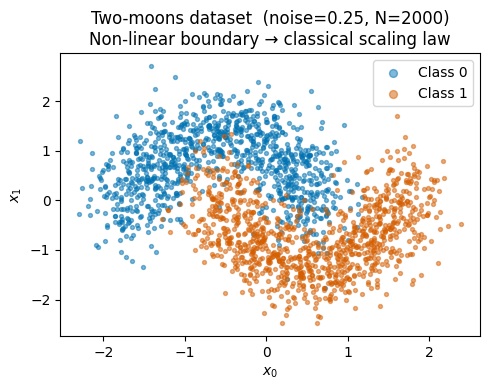

In [3]:
X, y = exp4.X, exp4.y

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#0072B2", "#D55E00"]
for cls, label in enumerate(["Class 0", "Class 1"]):
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], s=8, alpha=0.5, color=colors[cls], label=label)
ax.set_xlabel("$x_0$")
ax.set_ylabel("$x_1$")
ax.set_title("Two-moons dataset  (noise=0.25, N=2000)\nNon-linear boundary → classical scaling law")
ax.legend(markerscale=2)
plt.tight_layout()
fig

In [31]:
N_STEPS_Q = 1000
LR_QNG_MIN = 5e-4

In [29]:
print("=" * 68)
print("A. Classical MLP family")
print("=" * 68)
c_res = [exp4.run_classical(h) for h in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 24, 28, 32, 42, 64]]

A. Classical MLP family
  MLP H=  1  n_params=   5  loss=0.31  acc=87%  tr/N=0.276
  MLP H=  2  n_params=   9  loss=0.30  acc=87%  tr/N=0.092
  MLP H=  3  n_params=  13  loss=0.31  acc=87%  tr/N=0.093
  MLP H=  4  n_params=  17  loss=0.31  acc=87%  tr/N=0.075
  MLP H=  5  n_params=  21  loss=0.29  acc=87%  tr/N=0.061
  MLP H=  6  n_params=  25  loss=0.29  acc=88%  tr/N=0.055
  MLP H=  7  n_params=  29  loss=0.27  acc=88%  tr/N=0.046
  MLP H=  8  n_params=  33  loss=0.17  acc=93%  tr/N=0.023
  MLP H=  9  n_params=  37  loss=0.16  acc=94%  tr/N=0.033
  MLP H= 10  n_params=  41  loss=0.16  acc=94%  tr/N=0.033
  MLP H= 11  n_params=  45  loss=0.16  acc=94%  tr/N=0.047
  MLP H= 12  n_params=  49  loss=0.16  acc=94%  tr/N=0.046
  MLP H= 13  n_params=  53  loss=0.16  acc=93%  tr/N=0.028
  MLP H= 14  n_params=  57  loss=0.16  acc=94%  tr/N=0.037
  MLP H= 15  n_params=  61  loss=0.16  acc=94%  tr/N=0.034
  MLP H= 16  n_params=  65  loss=0.16  acc=94%  tr/N=0.036
  MLP H= 24  n_params=  97  loss

In [32]:
print("=" * 68)
print("B. QCNN + Adam")
print("=" * 68)
adam_res = [exp4.run_qcnn_adam(n) for n in exp4.Q_RANGE]

B. QCNN + Adam
  [QCNN+Adam] n=2…
    step    0  loss=0.7299  lr=0.01000
    step  100  loss=0.5351  lr=0.00978
    step  200  loss=0.3254  lr=0.00913
    step  300  loss=0.3754  lr=0.00813
    step  400  loss=0.2116  lr=0.00688
    step  500  loss=0.3045  lr=0.00549
    step  600  loss=0.2639  lr=0.00410
    step  700  loss=0.3587  lr=0.00284
    step  800  loss=0.2017  lr=0.00185
    step  900  loss=0.1909  lr=0.00122
    final  loss=0.25  acc=90%  tr/N=1.000
  [QCNN+Adam] n=3…
    step    0  loss=0.7811  lr=0.01000
    step  100  loss=0.3476  lr=0.00978
    step  200  loss=0.2000  lr=0.00913
    step  300  loss=0.2220  lr=0.00813
    step  400  loss=0.1113  lr=0.00688
    step  500  loss=0.1627  lr=0.00549
    step  600  loss=0.1402  lr=0.00410
    step  700  loss=0.1769  lr=0.00284
    step  800  loss=0.1272  lr=0.00185
    step  900  loss=0.1036  lr=0.00122
    final  loss=0.17  acc=93%  tr/N=1.000
  [QCNN+Adam] n=4…
    step    0  loss=0.6982  lr=0.01000
    step  100  loss=0.375

In [33]:
print("=" * 68)
print("C. QCNN + QNG_pb (pullback through W)")
print("=" * 68)
pb_res = [exp4.run_qcnn_qng_pb(n, n_steps=N_STEPS_Q, lr_qng_min=LR_QNG_MIN) for n in exp4.QNG_RANGE]

C. QCNN + QNG_pb (pullback through W)
  [QCNN+QNG_pb] n=2…
    step    0  loss=0.8410  lr_qng=0.00500
    step  100  loss=0.4757  lr_qng=0.00489
    step  200  loss=0.3382  lr_qng=0.00457
    step  300  loss=0.4215  lr_qng=0.00407
    step  400  loss=0.3550  lr_qng=0.00345
    step  500  loss=0.2375  lr_qng=0.00275
    step  600  loss=0.1604  lr_qng=0.00205
    step  700  loss=0.2146  lr_qng=0.00143
    step  800  loss=0.1621  lr_qng=0.00093
    step  900  loss=0.1931  lr_qng=0.00061
    final  loss=0.20  acc=92%
  [QCNN+QNG_pb] n=3…
    step    0  loss=0.6948  lr_qng=0.00500
    step  100  loss=0.3086  lr_qng=0.00489
    step  200  loss=0.1801  lr_qng=0.00457
    step  300  loss=0.1752  lr_qng=0.00407
    step  400  loss=0.3450  lr_qng=0.00345
    step  500  loss=0.1778  lr_qng=0.00275
    step  600  loss=0.0860  lr_qng=0.00205
    step  700  loss=0.1855  lr_qng=0.00143
    step  800  loss=0.0834  lr_qng=0.00093
    step  900  loss=0.1470  lr_qng=0.00061
    final  loss=0.17  acc=93%


In [37]:
print(f"\n{'Scenario':>20} {'n/H':>5} {'n_circ':>7} {'loss':>7} {'acc':>6}")
print("-" * 48)
for r in c_res:
    print(f"{'MLP':>20} {r['h']:>5}   {'–':>5} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in adam_res:
    print(f"{'QCNN+Adam':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in pb_res:
    print(f"{'QCNN+QNG_pb':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")


            Scenario   n/H  n_circ    loss    acc
------------------------------------------------
                 MLP     1       –    0.31    87%
                 MLP     2       –    0.30    87%
                 MLP     3       –    0.31    87%
                 MLP     4       –    0.31    87%
                 MLP     5       –    0.29    87%
                 MLP     6       –    0.29    88%
                 MLP     7       –    0.27    88%
                 MLP     8       –    0.17    93%
                 MLP     9       –    0.16    94%
                 MLP    10       –    0.16    94%
                 MLP    11       –    0.16    94%
                 MLP    12       –    0.16    94%
                 MLP    13       –    0.16    93%
                 MLP    14       –    0.16    94%
                 MLP    15       –    0.16    94%
                 MLP    16       –    0.16    94%
                 MLP    24       –    0.16    94%
                 MLP    28       –    0.16    94%


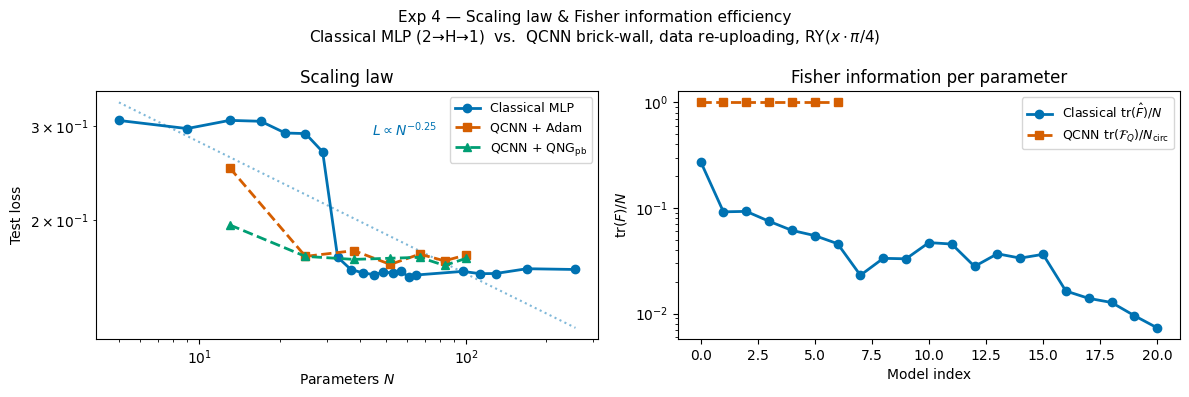

In [38]:
from scipy.stats import linregress

PAL   = {"c": "#0072B2", "adam": "#D55E00", "pb": "#009E73"}

def smooth(v, w=20):
    return np.convolve(v, np.ones(w) / w, mode="valid")

c_np  = [r["n_params"] for r in c_res]
c_l   = [r["test_loss"] for r in c_res]
c_tpn = [r["tr_f"] / r["n_params"] for r in c_res]
q_np  = [r["n_tot"] for r in adam_res]
q_l   = [r["test_loss"] for r in adam_res]
q_tpn = [r["tr_f"] / r["n_circ"] for r in adam_res]
p_np  = [r["n_tot"] for r in pb_res]
p_l   = [r["test_loss"] for r in pb_res]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    "Exp 4 — Scaling law & Fisher information efficiency\n"
    r"Classical MLP (2→H→1)  vs.  QCNN brick-wall, data re-uploading, $\mathrm{RY}(x\cdot\pi/4)$",
    fontsize=11,
)

ax = axes[0]
ax.loglog(c_np, c_l, "o-", color=PAL["c"], lw=2, label="Classical MLP")
sl, ic, *_ = linregress(np.log(c_np), np.log(c_l))
xf = np.geomspace(min(c_np), max(c_np), 200)
ax.loglog(xf, np.exp(ic) * xf**sl, ":", color=PAL["c"], alpha=0.5)
ax.text(0.55, 0.82, fr"$L \propto N^{{{sl:.2f}}}$", transform=ax.transAxes, color=PAL["c"], fontsize=10)
ax.loglog(q_np, q_l, "s--", color=PAL["adam"], lw=2, label="QCNN + Adam")
ax.loglog(p_np, p_l, "^--", color=PAL["pb"],   lw=2, label=r"QCNN + QNG$_\mathrm{pb}$")
ax.set_xlabel("Parameters $N$"); ax.set_ylabel("Test loss")
ax.set_title("Scaling law"); ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(range(len(c_res)), c_tpn, "o-", color=PAL["c"], lw=2,
            label=r"Classical $\mathrm{tr}(\hat{F})/N$")
ax.semilogy(range(len(adam_res)), q_tpn, "s--", color=PAL["adam"], lw=2,
            label=r"QCNN $\mathrm{tr}(\mathcal{F}_Q)/N_\mathrm{circ}$")
ax.set_xlabel("Model index"); ax.set_ylabel(r"$\mathrm{tr}(F)/N$")
ax.set_title("Fisher information per parameter"); ax.legend(fontsize=9)

plt.tight_layout()
fig

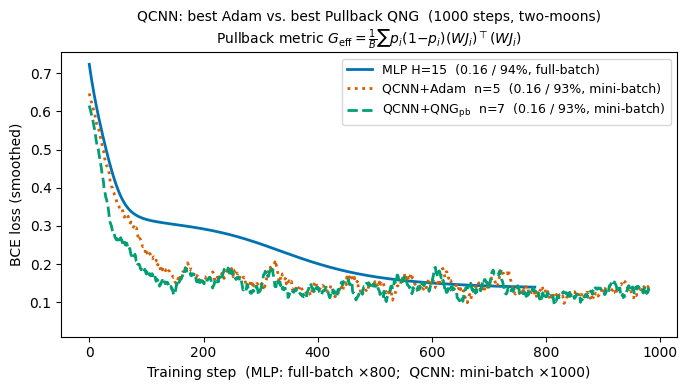

In [39]:
QNG_RANGE = exp4.QNG_RANGE

adam_by_n = {r["n_qubits"]: r for r in adam_res if r["n_qubits"] in QNG_RANGE}
pb_by_n   = {r["n_qubits"]: r for r in pb_res}

best_adam = min(adam_by_n.values(), key=lambda r: r["test_loss"])
best_pb   = min(pb_by_n.values(),   key=lambda r: r["test_loss"])
best_mlp  = min(c_res, key=lambda r: r["test_loss"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title(
    f"QCNN: best Adam vs. best Pullback QNG  ({exp4.N_STEPS_Q} steps, two-moons)\n"
    r"Pullback metric $G_\mathrm{eff} = \frac{1}{B}\sum p_i(1{-}p_i)(WJ_i)^\top(WJ_i)$",
    fontsize=10,
)

for res, col, ls, lbl in [
    (best_mlp,  PAL["c"],    "-",
     f"MLP H={best_mlp['h']}  ({best_mlp['test_loss']:.2f} / {best_mlp['test_acc']:.0%}, full-batch)"),
    (best_adam, PAL["adam"], ":",
     f"QCNN+Adam  n={best_adam['n_qubits']}  ({best_adam['test_loss']:.2f} / {best_adam['test_acc']:.0%}, mini-batch)"),
    (best_pb,   PAL["pb"],   "--",
     f"QCNN+QNG$_{{\\rm pb}}$  n={best_pb['n_qubits']}  ({best_pb['test_loss']:.2f} / {best_pb['test_acc']:.0%}, mini-batch)"),
]:
    s = smooth(res["losses"])
    ax.plot(s, color=col, lw=2, ls=ls, label=lbl)

ax.set_xlabel(f"Training step  (MLP: full-batch ×{exp4.N_STEPS_C};  QCNN: mini-batch ×{exp4.N_STEPS_Q})")
ax.set_ylabel("BCE loss (smoothed)")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(bottom=0.01)
plt.tight_layout()
fig

---
## Experiment 5 — Two-class Spiral: Scaling Law

A two-class Archimedean spiral (N_TURNS=3 full rotations per arm) has a continuously
complex decision boundary — no capacity threshold, so the classical MLP should exhibit
a clean power law L ∝ N^α across the full parameter range.

Same QCNN architecture and QNG_pb optimiser as Exp 4; only the dataset changes.

In [67]:
import exp5_spiral as exp5s
importlib.reload(exp5s)

<module 'exp5_spiral' from '/Users/disipio/development/qLM-fisher/exp5_spiral.py'>

In [100]:
N_TURNS = 1
NOISE = 0.05
N_STEPS_C = 1000

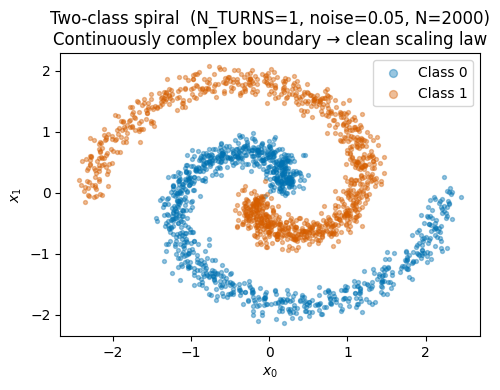

In [101]:
from sklearn.preprocessing import StandardScaler

X5_raw, y5 = exp5s.make_spiral(n_turns=N_TURNS, noise=NOISE)
X5 = StandardScaler().fit_transform(X5_raw)
exp5s.load_dataset(X5, y5)   # wire module-level X_tr/y_tr to this data

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#0072B2", "#D55E00"]
for cls, label in enumerate(["Class 0", "Class 1"]):
    mask = y5 == cls
    ax.scatter(X5[mask, 0], X5[mask, 1], s=8, alpha=0.4, color=colors[cls], label=label)
ax.set_xlabel("$x_0$"); ax.set_ylabel("$x_1$")
ax.set_title(f"Two-class spiral  (N_TURNS={N_TURNS}, noise={NOISE}, N=2000)\n"
             "Continuously complex boundary → clean scaling law")
ax.legend(markerscale=2)
plt.tight_layout()
fig

In [102]:
print("=" * 68)
print("A. Classical MLP family  (spiral)")
print("=" * 68)
c5_res = [exp5s.run_classical(h, n_steps=N_STEPS_C) for h in [1, 2, 3, 4, 8, 16, 32, 64]]

A. Classical MLP family  (spiral)
  MLP H=  1  n_params=   5  loss=0.57  acc=66%  tr/N=0.141
  MLP H=  2  n_params=   9  loss=0.47  acc=65%  tr/N=0.067
  MLP H=  3  n_params=  13  loss=0.22  acc=89%  tr/N=0.104
  MLP H=  4  n_params=  17  loss=0.23  acc=88%  tr/N=0.245
  MLP H=  8  n_params=  33  loss=0.05  acc=99%  tr/N=0.007
  MLP H= 16  n_params=  65  loss=0.03  acc=99%  tr/N=0.002
  MLP H= 32  n_params= 129  loss=0.02  acc=100%  tr/N=0.002
  MLP H= 64  n_params= 257  loss=0.02  acc=100%  tr/N=0.001


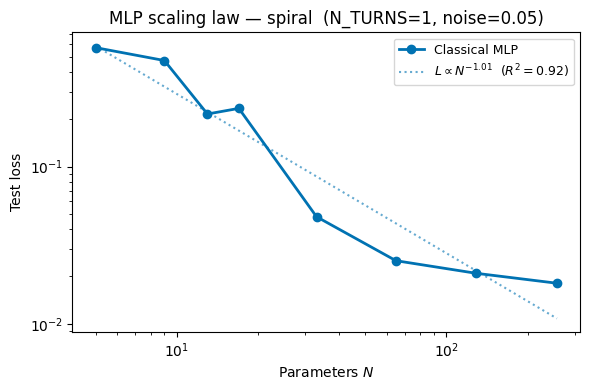

In [103]:
c5_np = [r["n_params"] for r in c5_res]
c5_l  = [r["test_loss"] for r in c5_res]

sl, ic, r_val, *_ = linregress(np.log(c5_np), np.log(c5_l))
xf = np.geomspace(min(c5_np), max(c5_np), 200)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(c5_np, c5_l, "o-", color=PAL["c"], lw=2, label="Classical MLP")
ax.loglog(xf, np.exp(ic) * xf**sl, ":", color=PAL["c"], alpha=0.6,
          label=fr"$L \propto N^{{{sl:.2f}}}$  ($R^2={r_val**2:.2f}$)")
ax.set_xlabel("Parameters $N$"); ax.set_ylabel("Test loss")
ax.set_title(f"MLP scaling law — spiral  (N_TURNS={N_TURNS}, noise={NOISE})")
ax.legend(fontsize=9)
plt.tight_layout()
fig

In [104]:
print("=" * 68)
print("B. QCNN + Adam  (spiral)")
print("=" * 68)
adam5_res = [exp5s.run_qcnn_adam(n, n_steps=N_STEPS_Q) for n in exp5s.Q_RANGE]

B. QCNN + Adam  (spiral)
  [QCNN+Adam] n=2…
    step    0  loss=0.6265  lr=0.01000
    step  100  loss=0.3122  lr=0.00978
    step  200  loss=0.2522  lr=0.00913
    step  300  loss=0.1899  lr=0.00813
    step  400  loss=0.2326  lr=0.00688
    step  500  loss=0.2483  lr=0.00549
    step  600  loss=0.1558  lr=0.00410
    step  700  loss=0.0719  lr=0.00284
    step  800  loss=0.0882  lr=0.00185
    step  900  loss=0.1692  lr=0.00122
    final  loss=0.13  acc=95%  tr/N=1.000
  [QCNN+Adam] n=3…
    step    0  loss=0.7501  lr=0.01000
    step  100  loss=0.4879  lr=0.00978
    step  200  loss=0.2430  lr=0.00913
    step  300  loss=0.1521  lr=0.00813
    step  400  loss=0.1506  lr=0.00688
    step  500  loss=0.1466  lr=0.00549
    step  600  loss=0.1001  lr=0.00410
    step  700  loss=0.0743  lr=0.00284
    step  800  loss=0.0598  lr=0.00185
    step  900  loss=0.0718  lr=0.00122
    final  loss=0.08  acc=99%  tr/N=1.000
  [QCNN+Adam] n=4…
    step    0  loss=0.6296  lr=0.01000
    step  100  

In [105]:
print("=" * 68)
print("C. QCNN + QNG_pb  (spiral)")
print("=" * 68)
pb5_res = [exp5s.run_qcnn_qng_pb(n, n_steps=N_STEPS_Q, lr_qng_min=LR_QNG_MIN) for n in exp5s.QNG_RANGE]

C. QCNN + QNG_pb  (spiral)
  [QCNN+QNG_pb] n=2…
    step    0  loss=0.6719  lr_qng=0.00500
    step  100  loss=0.3969  lr_qng=0.00489
    step  200  loss=0.2510  lr_qng=0.00457
    step  300  loss=0.1973  lr_qng=0.00407
    step  400  loss=0.1662  lr_qng=0.00345
    step  500  loss=0.1907  lr_qng=0.00275
    step  600  loss=0.1739  lr_qng=0.00205
    step  700  loss=0.1768  lr_qng=0.00143
    step  800  loss=0.1467  lr_qng=0.00093
    step  900  loss=0.0601  lr_qng=0.00061
    final  loss=0.12  acc=96%
  [QCNN+QNG_pb] n=3…
    step    0  loss=0.7421  lr_qng=0.00500
    step  100  loss=0.4375  lr_qng=0.00489
    step  200  loss=0.3884  lr_qng=0.00457
    step  300  loss=0.1634  lr_qng=0.00407
    step  400  loss=0.1317  lr_qng=0.00345
    step  500  loss=0.1355  lr_qng=0.00275
    step  600  loss=0.1207  lr_qng=0.00205
    step  700  loss=0.1058  lr_qng=0.00143
    step  800  loss=0.1352  lr_qng=0.00093
    step  900  loss=0.0802  lr_qng=0.00061
    final  loss=0.11  acc=100%
  [QCNN+QN

In [108]:
print(f"\n{'Scenario':>20} {'n/H':>5} {'n_circ':>7} {'loss':>7} {'acc':>6}")
print("-" * 48)
for r in c5_res:
    print(f"{'MLP':>20} {r['h']:>5}   {'–':>5} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in adam5_res:
    print(f"{'QCNN+Adam':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")
for r in pb5_res:
    print(f"{'QCNN+QNG_pb':>20} {r['n_qubits']:>5} {r['n_circ']:>7} {r['test_loss']:>7.2f} {r['test_acc']:>6.0%}")


            Scenario   n/H  n_circ    loss    acc
------------------------------------------------
                 MLP     1       –    0.57    66%
                 MLP     2       –    0.47    65%
                 MLP     3       –    0.22    89%
                 MLP     4       –    0.23    88%
                 MLP     8       –    0.05    99%
                 MLP    16       –    0.03    99%
                 MLP    32       –    0.02   100%
                 MLP    64       –    0.02   100%
           QCNN+Adam     2       9    0.13    95%
           QCNN+Adam     3      18    0.08    99%
           QCNN+Adam     4      27    0.04    99%
           QCNN+Adam     5      36    0.03   100%
           QCNN+Adam     6      45    0.03   100%
           QCNN+Adam     7      54    0.03   100%
           QCNN+Adam     8      63    0.02   100%
         QCNN+QNG_pb     2       9    0.12    96%
         QCNN+QNG_pb     3      18    0.11   100%
         QCNN+QNG_pb     4      27    0.05    99%


In [ ]:
c5_np  = [r["n_params"] for r in c5_res]
c5_l   = [r["test_loss"] for r in c5_res]
c5_tpn = [r["tr_f"] / r["n_params"] for r in c5_res]
q5_np  = [r["n_tot"] for r in adam5_res]
q5_l   = [r["test_loss"] for r in adam5_res]
q5_tpn = [r["tr_f"] / r["n_circ"] for r in adam5_res]
p5_np  = [r["n_tot"] for r in pb5_res]
p5_l   = [r["test_loss"] for r in pb5_res]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(
    f"Exp 5 — Spiral scaling law & Fisher information efficiency  (N_TURNS={N_TURNS})\n"
    r"Classical MLP (2→H→1)  vs.  QCNN brick-wall, data re-uploading, $\mathrm{RY}(x\cdot\pi/4)$",
    fontsize=11,
)

ax = axes[0]
ax.loglog(c5_np, c5_l, "o-", color=PAL["c"], lw=2, label="Classical MLP")
sl, ic, *_ = linregress(np.log(c5_np), np.log(c5_l))
xf = np.geomspace(min(c5_np), max(c5_np), 200)
ax.loglog(xf, np.exp(ic) * xf**sl, ":", color=PAL["c"], alpha=0.5)
ax.text(0.55, 0.82, fr"$L \propto N^{{{sl:.2f}}}$", transform=ax.transAxes, color=PAL["c"], fontsize=10)
ax.loglog(q5_np, q5_l, "s--", color=PAL["adam"], lw=2, label="QCNN + Adam")
ax.loglog(p5_np, p5_l, "^--", color=PAL["pb"],   lw=2, label=r"QCNN + QNG$_\mathrm{pb}$")
ax.set_xlabel("Parameters $N$"); ax.set_ylabel("Test loss")
ax.set_title("Scaling law  (spiral)"); ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(range(len(c5_res)), c5_tpn, "o-", color=PAL["c"], lw=2,
            label=r"Classical $\mathrm{tr}(\hat{F})/N$")
ax.semilogy(range(len(adam5_res)), q5_tpn, "s--", color=PAL["adam"], lw=2,
            label=r"QCNN $\mathrm{tr}(\mathcal{F}_Q)/N_\mathrm{circ}$")
ax.set_xlabel("Model index"); ax.set_ylabel(r"$\mathrm{tr}(F)/N$")
ax.set_title("Fisher information per parameter  (spiral)"); ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig("plots/exp5_scaling_fisher.png", dpi=300, bbox_inches="tight")
fig

In [ ]:
adam5_by_n = {r["n_qubits"]: r for r in adam5_res if r["n_qubits"] in exp5s.QNG_RANGE}
pb5_by_n   = {r["n_qubits"]: r for r in pb5_res}

best5_adam = min(adam5_by_n.values(), key=lambda r: r["test_loss"])
best5_pb   = min(pb5_by_n.values(),   key=lambda r: r["test_loss"])
best5_mlp  = min(c5_res,              key=lambda r: r["test_loss"])

fig, ax = plt.subplots(figsize=(7, 4))
ax.set_title(
    f"Spiral: best Adam vs. best Pullback QNG  (N_TURNS={N_TURNS}, noise={NOISE})\n"
    r"Pullback metric $G_\mathrm{eff} = \frac{1}{B}\sum p_i(1{-}p_i)(WJ_i)^\top(WJ_i)$",
    fontsize=10,
)

for res, col, ls, lbl in [
    (best5_mlp,  PAL["c"],    "-",
     f"MLP H={best5_mlp['h']}  ({best5_mlp['test_loss']:.3f} / {best5_mlp['test_acc']:.0%}, full-batch)"),
    (best5_adam, PAL["adam"], ":",
     f"QCNN+Adam  n={best5_adam['n_qubits']}  ({best5_adam['test_loss']:.3f} / {best5_adam['test_acc']:.0%}, mini-batch)"),
    (best5_pb,   PAL["pb"],   "--",
     f"QCNN+QNG$_{{\\rm pb}}$  n={best5_pb['n_qubits']}  ({best5_pb['test_loss']:.3f} / {best5_pb['test_acc']:.0%}, mini-batch)"),
]:
    s = smooth(res["losses"])
    ax.plot(s, color=col, lw=2, ls=ls, label=lbl)

ax.set_xlabel(f"Training step  (MLP: full-batch ×{N_STEPS_C};  QCNN: mini-batch ×{N_STEPS_Q})")
ax.set_ylabel("BCE loss (smoothed)")
ax.legend(fontsize=9, loc="upper right")
ax.set_ylim(bottom=0.005)
plt.tight_layout()
fig.savefig("plots/exp5_bce_comparison.png", dpi=300, bbox_inches="tight")
fig